# Project Title : Predicting used Car Price

## Step 1

### 1.1 Import libraries : Load required libraries for data handling, visualization, preprocessing, and machine learning models

In [617]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score 
import pickle

## Step 2

### 2.1 Load dataset

In [581]:
df_new = pd.read_csv("usedCars.csv")
df_new.head(5)

,Id,Company,Model,Variant,FuelType,Colour,Kilometer,BodyStyle,TransmissionType,ManufactureDate,ModelYear,CngKit,Price,Owner,DealerState,DealerName,City,Warranty,QualityScore
0,555675,MARUTI SUZUKI,CELERIO(2017-2019),1.0 ZXI AMT O,PETROL,Silver,33197,HATCHBACK,NaN,2018-02-01,2018,NaN,5.75 Lakhs,1st Owner,Karnataka,Top Gear Cars,Bangalore,1,7.8
1,556383,MARUTI SUZUKI,ALTO,LXI,PETROL,Red,10322,HATCHBACK,Manual,2021-03-01,2021,NaN,4.35 Lakhs,1st Owner,Karnataka,Renew 4 u Automobiles PVT Ltd,Bangalore,1,8.3
2,556422,HYUNDAI,GRAND I10,1.2 KAPPA ASTA,PETROL,Grey,37889,HATCHBACK,Manual,2015-03-01,2015,NaN,4.7 Lakhs,1st Owner,Karnataka,Anant Cars Auto Pvt Ltd,Bangalore,1,7.9
3,556771,TATA,NEXON,XT PLUS,PETROL,A Blue,13106,HATCHBACK,NaN,2020-08-01,2020,NaN,9.9 Lakhs,1st Owner,Karnataka,Adeep Motors,Bangalore,1,8.1
4,559619,FORD,FIGO,EXI DURATORQ 1.4,DIESEL,Silver,104614,HATCHBACK,Manual,2010-11-01,2010,NaN,2.7 Lakhs,2nd Owner,Karnataka,Zippy Automart,Bangalore,0,7.5


## Step 3

### Exploratory Data Analysis (EDA)  

Inspect Dataset : These lightweight checks are essential to detect missing data, wrong types, and duplicates

3.1 Checking dataset shape, column names, and duplicate rows

In [582]:
print(f"Shape of the dataset(Rows and Columns) :{df_new.shape}\n")
print(f"Column names: {df_new.columns}\n")
print(f"Number of duplicate rows: {df_new.duplicated().sum()}")

Shape of the dataset(Rows and Columns) :(1064, 19)

Column names: Index(['Id', 'Company', 'Model', 'Variant', 'FuelType', 'Colour', 'Kilometer',
       'BodyStyle', 'TransmissionType', 'ManufactureDate', 'ModelYear',
       'CngKit', 'Price', 'Owner', 'DealerState', 'DealerName', 'City',
       'Warranty', 'QualityScore'],
      dtype='object')

Number of duplicate rows: 0


3.2 It returns (rows, columns), column dtypes and non-null counts  

In [583]:
df_new.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1064 entries, 0 to 1063
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Id                1064 non-null   int64  
 1   Company           1064 non-null   object 
 2   Model             1064 non-null   object 
 3   Variant           1064 non-null   object 
 4   FuelType          1063 non-null   object 
 5   Colour            1064 non-null   object 
 6   Kilometer         1064 non-null   int64  
 7   BodyStyle         1064 non-null   object 
 8   TransmissionType  350 non-null    object 
 9   ManufactureDate   1064 non-null   object 
 10  ModelYear         1064 non-null   int64  
 11  CngKit            22 non-null     object 
 12  Price             1064 non-null   object 
 13  Owner             1064 non-null   object 
 14  DealerState       1064 non-null   object 
 15  DealerName        1064 non-null   object 
 16  City              1064 non-null   object 


3.3 Dataset Description : Gives summary statistics for numeric columns

In [584]:
df_new.describe()

,Id,Kilometer,ModelYear,Warranty,QualityScore
count,1064.000000,1064.000000,1064.000000,1064.000000,1064.000000
mean,568156.542293,52807.187970,2016.864662,0.738722,7.770207
std,16438.139974,33840.296979,2.996786,0.439538,0.719717
min,525978.000000,101.000000,2003.000000,0.000000,0.000000
25%,555321.500000,32113.500000,2015.000000,0.000000,7.500000
50%,572753.000000,49432.000000,2017.000000,1.000000,7.800000
75%,583072.750000,68828.500000,2019.000000,1.000000,8.100000
max,589122.000000,640000.000000,2023.000000,1.000000,9.400000


3.4 Counts missing values per column

In [585]:
print(f"{df_new.isnull().sum().sort_values(ascending=False)}\n===================================\n{df_new.isnull().sum()/len(df_new.isnull()*100)}")

CngKit              1042
TransmissionType     714
FuelType               1
Model                  0
Company                0
Id                     0
Colour                 0
Kilometer              0
BodyStyle              0
ManufactureDate        0
Variant                0
ModelYear              0
Price                  0
Owner                  0
DealerState            0
DealerName             0
City                   0
Warranty               0
QualityScore           0
dtype: int64
Id                  0.000000
Company             0.000000
Model               0.000000
Variant             0.000000
FuelType            0.000940
Colour              0.000000
Kilometer           0.000000
BodyStyle           0.000000
TransmissionType    0.671053
ManufactureDate     0.000000
ModelYear           0.000000
CngKit              0.979323
Price               0.000000
Owner               0.000000
DealerState         0.000000
DealerName          0.000000
City                0.000000
Warranty           

In [586]:
df_new.dropna(subset=['FuelType'],inplace=True)
df_new['TransmissionType'] = df_new['TransmissionType'].fillna("Unknown")
df_new['CngKit'] = df_new['CngKit'].fillna("No")

In [587]:
df_new.isnull().sum()

Id                  0
Company             0
Model               0
Variant             0
FuelType            0
Colour              0
Kilometer           0
BodyStyle           0
TransmissionType    0
ManufactureDate     0
ModelYear           0
CngKit              0
Price               0
Owner               0
DealerState         0
DealerName          0
City                0
Warranty            0
QualityScore        0
dtype: int64

In [588]:
df_new = df_new.drop("Id",axis=1)

In [589]:
df_new['Price'].unique()

array(['5.75 Lakhs', '4.35 Lakhs', '4.7 Lakhs', '9.9 Lakhs', '2.7 Lakhs',
       '9.99 Lakhs', '6.75 Lakhs', '6 Lakhs', '4.8 Lakhs', '2.4 Lakhs',
       '6.5 Lakhs', '5 Lakhs', '11.35 Lakhs', '8.75 Lakhs', '13.5 Lakhs',
       '5.95 Lakhs', '7.55 Lakhs', '4.1 Lakhs', '5.25 Lakhs',
       '4.85 Lakhs', '6.45 Lakhs', '15.45 Lakhs', '7.15 Lakhs',
       '6.55 Lakhs', '2.35 Lakhs', '5.55 Lakhs', '3.75 Lakhs',
       '6.2 Lakhs', '2.75 Lakhs', '9.5 Lakhs', '5.3 Lakhs', '6.25 Lakhs',
       '8.25 Lakhs', '7.6 Lakhs', '4.95 Lakhs', '4.55 Lakhs',
       '3.45 Lakhs', '3.35 Lakhs', '6.8 Lakhs', '5.15 Lakhs',
       '3.15 Lakhs', '8.5 Lakhs', '8.9 Lakhs', '2.95 Lakhs', '7.3 Lakhs',
       '17.75 Lakhs', '7.75 Lakhs', '7.35 Lakhs', '4.2 Lakhs',
       '6.1 Lakhs', '5.65 Lakhs', '5.85 Lakhs', '7.85 Lakhs',
       '6.95 Lakhs', '8.85 Lakhs', '10.75 Lakhs', '4.45 Lakhs',
       '4.75 Lakhs', '8.95 Lakhs', '7.25 Lakhs', '5.5 Lakhs',
       '5.49 Lakhs', '2.85 Lakhs', '14 Lakhs', '5.7 Lakhs', '9.75 La

In [590]:
df_new['Price'] = df_new['Price'].str.replace(",","")

In [591]:
def price(x):
    x = str(x).replace(" Lakhs","").strip()
    value = float(x)
    if value < 1000:
        return value*100000
    else:
        return value
df_new['Price'] = df_new['Price'].apply(price)

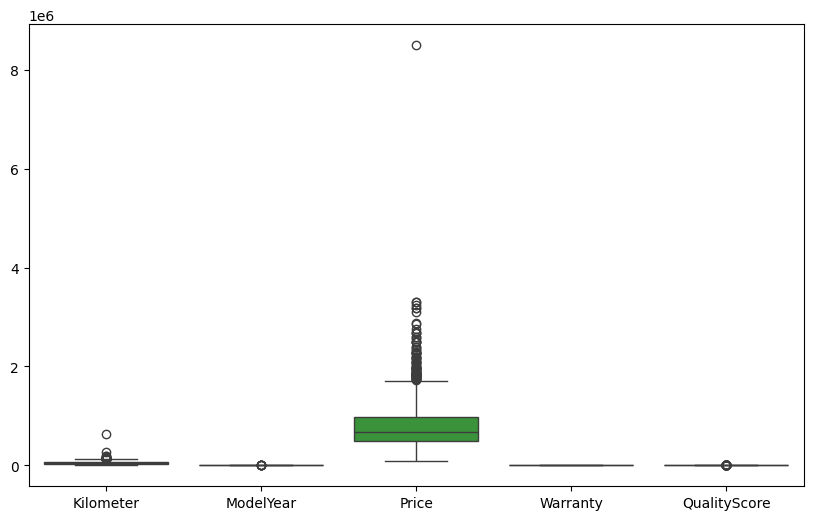

In [592]:
plt.figure(figsize=(10,6))
sns.boxplot(data = df_new)
plt.show()

In [593]:
Q1 = df_new['Price'].quantile(0.25)
Q3 = df_new['Price'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(lower_bound, upper_bound)
df = df_new[df_new['Price'] <= 1728750]

print("Old shape:", df_new.shape)
print("New shape:", df.shape)
print("Removed rows:", df_new.shape[0] - df.shape[0])

-261250.00000000017 1728750.0
Old shape: (1063, 18)
New shape: (978, 18)
Removed rows: 85


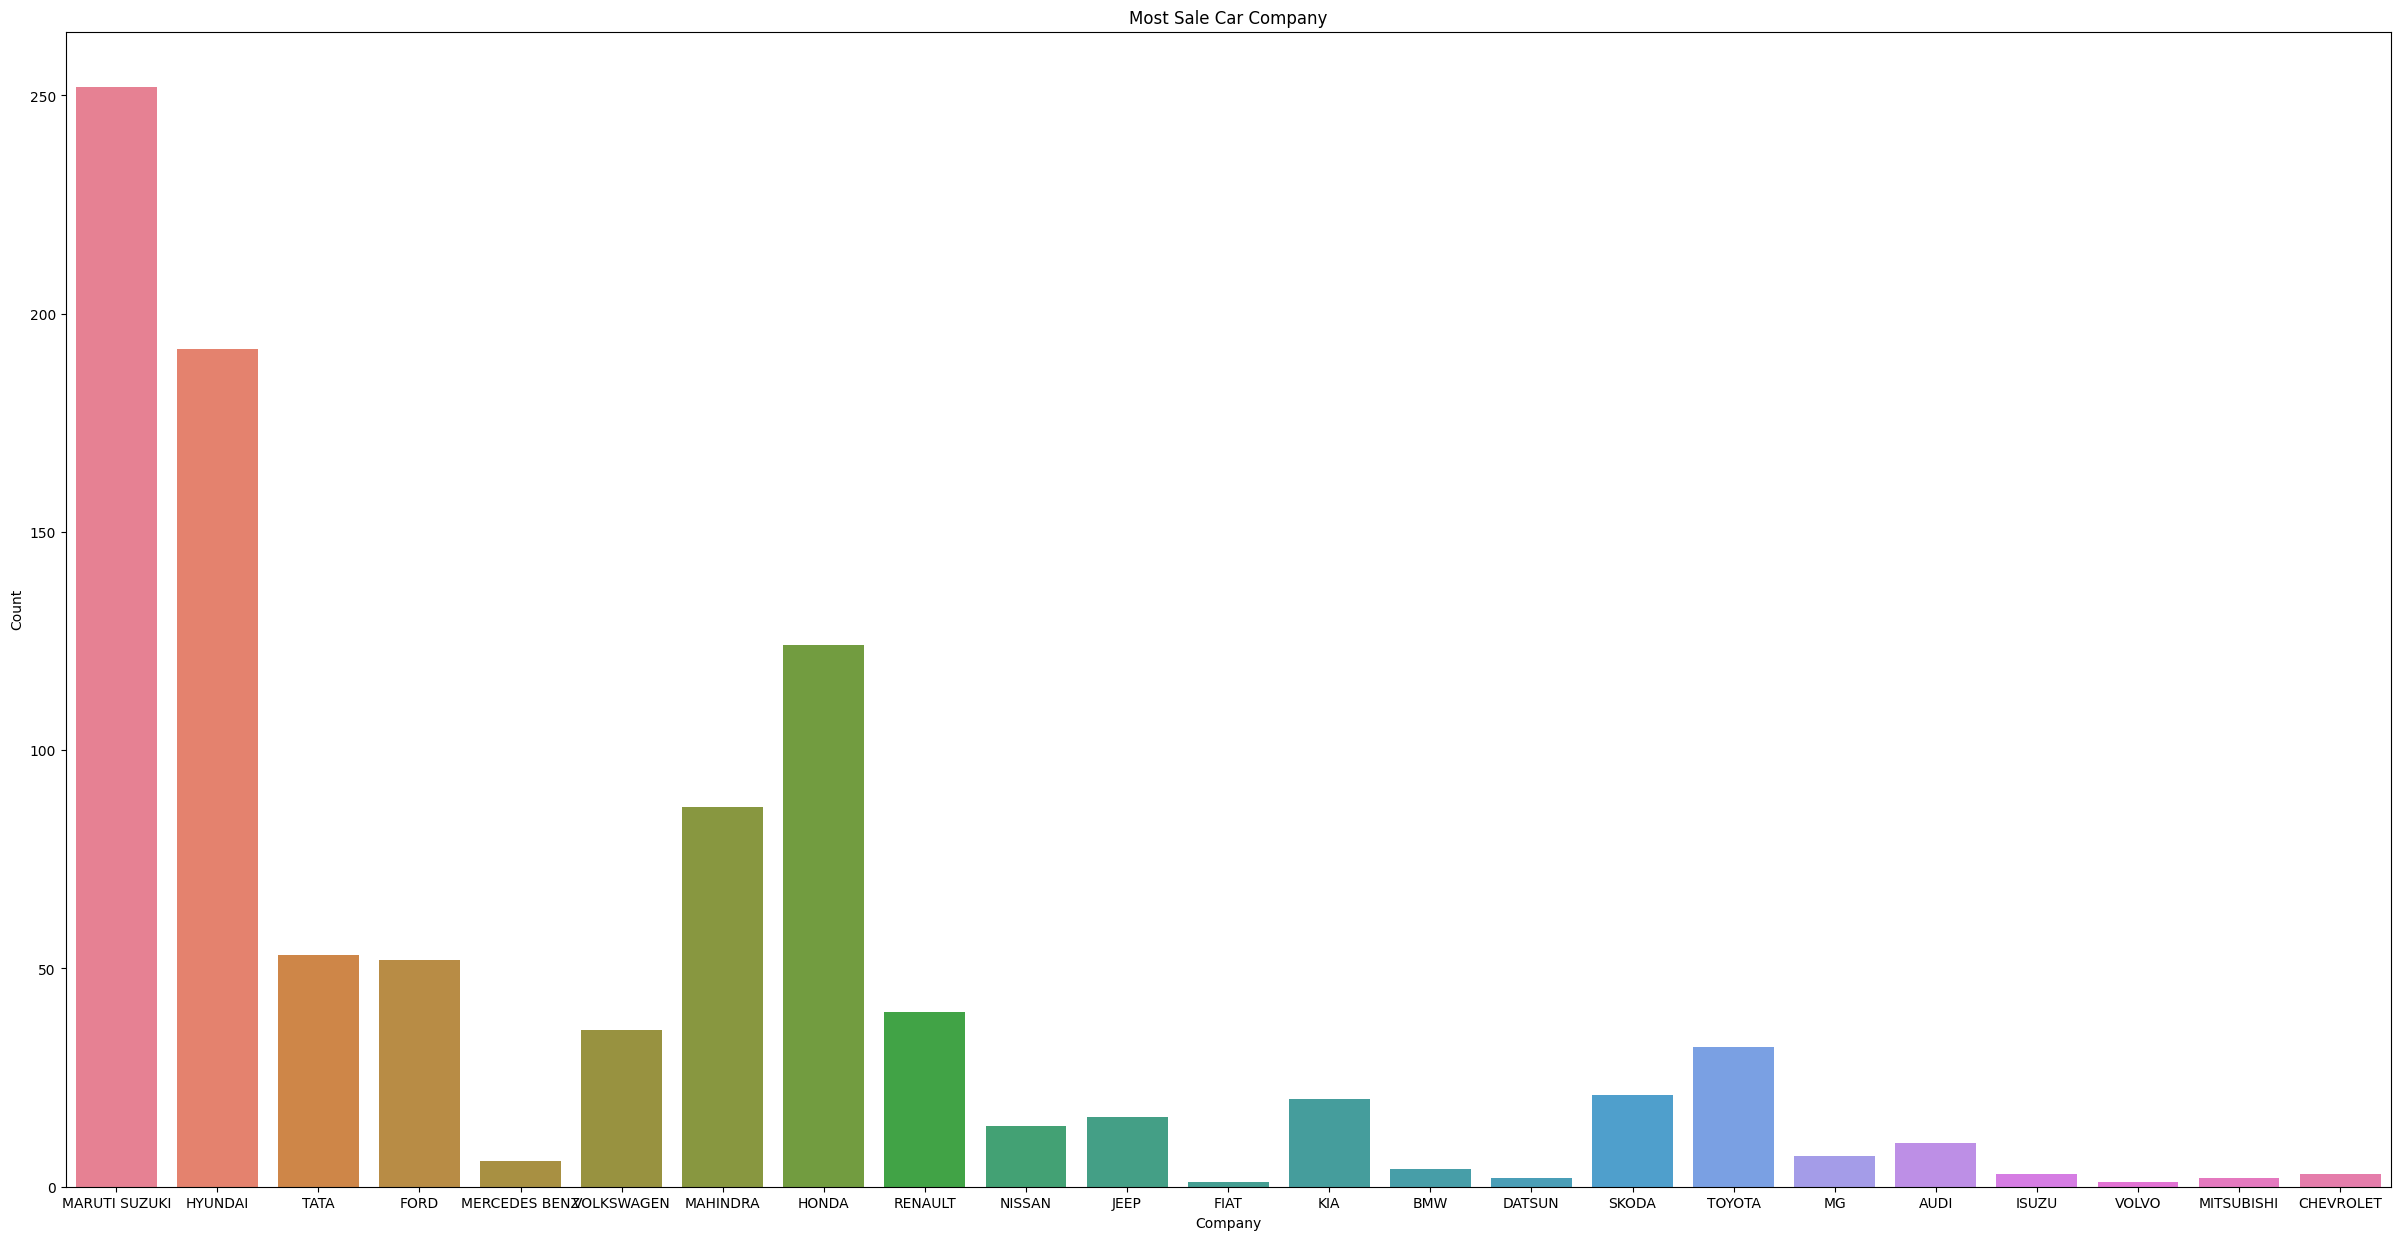

In [594]:
plt.figure(figsize=(30,15))
sns.countplot(data= df, x='Company', hue='Company')
plt.title("Most Sale Car Company")
plt.xlabel("Company")
plt.ylabel("Count")
plt.show()

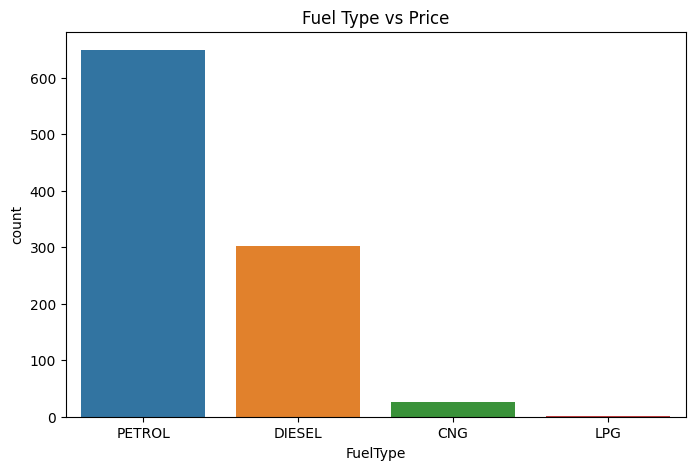

In [595]:
plt.figure(figsize=(8,5))
sns.countplot(data=df,x="FuelType", hue="FuelType")
plt.title("Fuel Type vs Price")
plt.show()

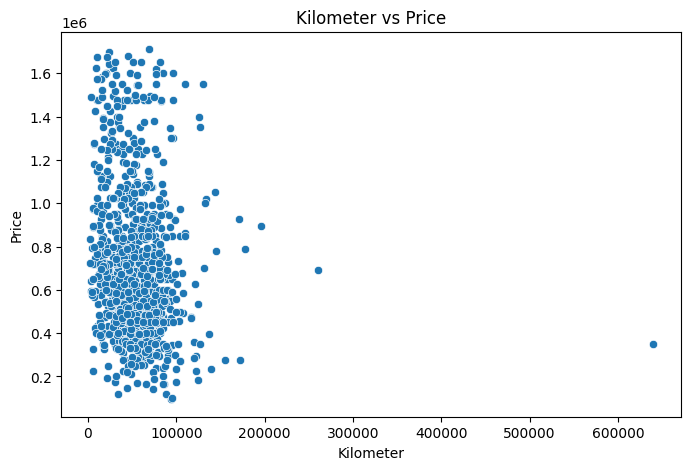

In [596]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=df["Kilometer"], y=df["Price"])
plt.title("Kilometer vs Price")
plt.show()

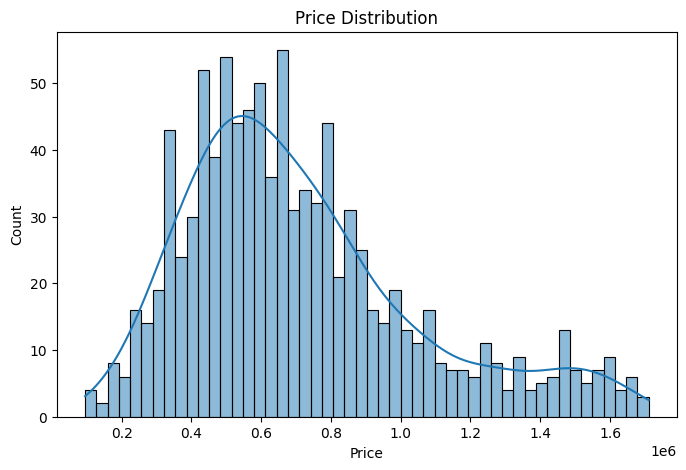

In [597]:
plt.figure(figsize=(8,5))
sns.histplot(df["Price"], bins=50, kde=True)
plt.title("Price Distribution")
plt.show()


In [598]:
df['Owner'].value_counts().sort_index(ascending=False)

Owner
4th Owner      1
3rd Owner      8
2nd Owner    148
1st Owner    821
Name: count, dtype: int64

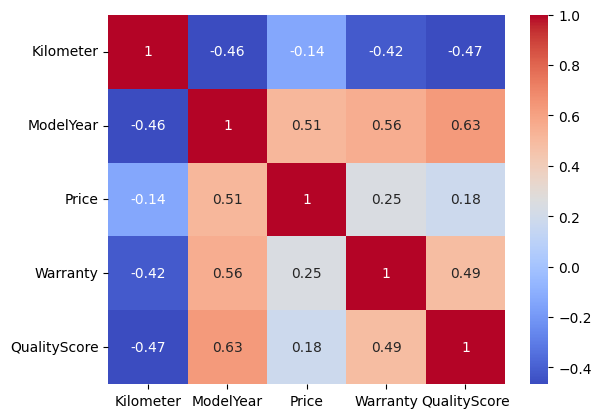

In [599]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap= "coolwarm")
plt.show() 

In [600]:
df.shape

(978, 18)

In [601]:
df['CarAge'] = 2026 - df['ModelYear']
df['Km_per_Year'] = df['Kilometer'] / df['CarAge']

C:\Users\MADHIVANAN\AppData\Local\Temp\ipykernel_2064\3796385826.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['CarAge'] = 2026 - df['ModelYear']
C:\Users\MADHIVANAN\AppData\Local\Temp\ipykernel_2064\3796385826.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Km_per_Year'] = df['Kilometer'] / df['CarAge']


In [602]:
df["Owner"] = df["Owner"].str.extract("(\d)").astype(int)
df['CngKit'] = df['CngKit'].apply(lambda x: 1 if x=="Yes" else 0)

<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
C:\Users\MADHIVANAN\AppData\Local\Temp\ipykernel_2064\2258069181.py:1: SyntaxWarning: invalid escape sequence '\d'
  df["Owner"] = df["Owner"].str.extract("(\d)").astype(int)
C:\Users\MADHIVANAN\AppData\Local\Temp\ipykernel_2064\2258069181.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Owner"] = df["Owner"].str.extract("(\d)").astype(int)
C:\Users\MADHIVANAN\AppData\Local\Temp\ipykernel_2064\2258069181.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/use

In [603]:
print(f"No of Companies: {df['Company'].nunique()}")
print(f"No of Models: {df['Model'].nunique()}")
print(f"No of FuelTypes: {df['FuelType'].nunique()}")
print(f"No of BodyStyles: {df['BodyStyle'].nunique()}")
print(f"No of TransmissionTypes: {df['TransmissionType'].nunique()}")
print(f"No of CngKit: {df['CngKit'].nunique()}")
print(f"No of DealerStates: {df['DealerState'].nunique()}")
print(f"No of Variant: {df['Variant'].nunique()}")

No of Companies: 23
No of Models: 195
No of FuelTypes: 4
No of BodyStyles: 10
No of TransmissionTypes: 10
No of CngKit: 1
No of DealerStates: 10
No of Variant: 524


In [604]:
df['Model_TE'] = df.groupby('Model')['Price'].transform('mean')
df_new['Variant_TE'] = df.groupby('Variant')['Price'].transform('mean')
top_colors = df['Colour'].value_counts().nlargest(8).index
df['Colour'] = df['Colour'].apply(lambda x: x if x in top_colors else 'Other')

C:\Users\MADHIVANAN\AppData\Local\Temp\ipykernel_2064\1453113279.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Model_TE'] = df.groupby('Model')['Price'].transform('mean')
C:\Users\MADHIVANAN\AppData\Local\Temp\ipykernel_2064\1453113279.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Colour'] = df['Colour'].apply(lambda x: x if x in top_colors else 'Other')


In [605]:
#df_new.drop(['Model', 'Variant', 'CngKit', 'TransmissionType', 'City', 'ManufactureDate', 'ModelYear', 'DealerName'], axis=1, inplace=True)
df.drop(['Model', 'Variant', 'City', 'ManufactureDate', 'ModelYear', 'Kilometer', 'DealerName'], axis=1, inplace=True)
df.shape

C:\Users\MADHIVANAN\AppData\Local\Temp\ipykernel_2064\4034797953.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop(['Model', 'Variant', 'City', 'ManufactureDate', 'ModelYear', 'Kilometer', 'DealerName'], axis=1, inplace=True)


(978, 14)

In [606]:
low_card_cols = ['Company','FuelType', 'Colour', 'CngKit', 'TransmissionType', 'BodyStyle','DealerState']
df = pd.get_dummies(df, columns=low_card_cols, drop_first=True)

In [607]:
df.shape

(978, 67)

In [608]:
x = df.drop("Price", axis=1)
y = df["Price"]

In [609]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [610]:
scaler = StandardScaler()
X_train = scaler.fit_transform(x_train)
X_test = scaler.transform(x_test)

In [611]:
models = [LinearRegression(), RandomForestRegressor(), GradientBoostingRegressor(), Ridge(alpha=10)]

In [612]:
for Model in models:
    print(f"-----------------------------------{Model}-----------------------------------") 
    Model.fit(x_train, y_train)
    y_pred = Model.predict(x_test)
    print(f"R2 Score = {r2_score(y_test, y_pred)}")
    MSE = mean_squared_error(y_test, y_pred)
    print(f"MSE = {MSE}")
    print(f"RMSE = {np.sqrt(MSE)}")
    print(f"MAE = {mean_absolute_error(y_test, y_pred)}")

-----------------------------------LinearRegression()-----------------------------------
R2 Score = 0.8853209086531968
MSE = 12523968408.48386
RMSE = 111910.53752209333
MAE = 82676.9454008622
-----------------------------------RandomForestRegressor()-----------------------------------
R2 Score = 0.8875776585850857
MSE = 12277511408.163265
RMSE = 110803.93227752915
MAE = 79336.22448979592
-----------------------------------GradientBoostingRegressor()-----------------------------------
R2 Score = 0.895708064520284
MSE = 11389599358.244404
RMSE = 106722.0659387945
MAE = 76632.41447524479
-----------------------------------Ridge(alpha=10)-----------------------------------
R2 Score = 0.8869511953203038
MSE = 12345926722.978392
RMSE = 111112.22580336689
MAE = 80718.3025759888


In [613]:
GBR = GradientBoostingRegressor(random_state=42)
param_grid = {'n_estimators': [100, 200, 300],'learning_rate': [0.01, 0.05, 0.1],'max_depth': [3, 4, 5],'min_samples_split': [2, 5, 10],'min_samples_leaf': [1, 2, 4]}

In [614]:
grid = GridSearchCV(estimator=GBR,param_grid=param_grid,cv=5,scoring='r2',n_jobs=-1)
grid.fit(x_train, y_train)
print("Best Parameters:", grid.best_params_)
print("Best CV Score:", grid.best_score_)

Best Parameters: {'learning_rate': 0.1, 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
Best CV Score: 0.8877524728334516


In [615]:
best_GBR = grid.best_estimator_

y_pred = best_GBR.predict(x_test)

r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)

print(f"R2 Score = {r2_score(y_test, y_pred)}")
MSE = mean_squared_error(y_test, y_pred)
print(f"MSE = {MSE}")
print(f"RMSE = {np.sqrt(MSE)}")
print(f"MAE = {mean_absolute_error(y_test, y_pred)}")


R2 Score = 0.8847118891749697
MSE = 12590478707.928093
RMSE = 112207.30238236766
MAE = 78921.45045108926


In [618]:
with open('gradient_boosting_model.pkl', 'wb') as file:
    pickle.dump(best_GBR, file)
print("Model saved successfully!")


Model saved successfully!


In [ ]:
with open('gradient_boosting_model.pkl', 'rb') as file:
    loaded_model = pickle.load(file)
print("Model loaded successfully!")